<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/05_logit_discrepancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 5 — Binomial with logit-scale discrepancy

Return to an exact Binomial likelihood. Add one local error per distance bin on the logit scale, with a shared scale controlling how large those departures can be.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/broadie_2018_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,0.28,45198,45183,0.999668
1,0.97,183020,182899,0.999339
2,1.93,169503,168594,0.994637
3,2.92,113094,108953,0.963384
4,3.93,73855,64740,0.876582
5,4.94,53659,41106,0.766060
6,5.94,42991,28205,0.656068
7,6.95,37050,21334,0.575816
8,7.95,33275,16615,0.499324
9,8.95,30836,13503,0.437897


In [3]:
def plot_rate(draws, data, title, *, median_label="median", show_observed=True, ylim=(-0.05, 1.05), show_bounds=False):
    """Plot a probability/rate relationship against continuous putting distance."""
    x = data["distance_ft"].to_numpy()
    curve_dim = next(dim for dim in draws.dims if dim not in ("chain", "draw"))
    order = np.argsort(x)
    draws = draws.isel({curve_dim: order})
    x = x[order]

    median = draws.median(dim=("chain", "draw"))
    interval = draws.azstats.hdi(prob=0.90)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(
        x,
        interval.sel(ci_bound="lower"),
        interval.sel(ci_bound="upper"),
        alpha=0.22,
        label="90% HDI",
    )
    ax.plot(x, median, label=median_label)
    if show_observed:
        ax.scatter(x, data["rate"].to_numpy()[order], s=30, color="black", label="observed")
    if show_bounds:
        ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
        ax.axhline(1, color="0.6", linewidth=0.8, linestyle="--")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Proportion made",
        title=title,
    )
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8, frameon=False)
    return ax

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model

$$
\operatorname{logit}(p_j)=\operatorname{logit}(p_{base,j})+\sigma_{logit}\eta_j,
\qquad \eta_j\sim N(0,1).
$$

This keeps $p_j$ inside $[0,1]$ while allowing each bin to depart from the mechanistic curve.

In [4]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}

with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_distance = pm.LogNormal("sigma_distance", mu=np.log(0.10), sigma=0.7)
    distance_tolerance = 3.0
    overshot = 1.0

    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_angle = pm.Deterministic(
        "p_angle",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    p_distance = pm.Deterministic(
        "p_distance",
        pm.math.invprobit(
            (distance_tolerance - overshot) / ((distance + overshot) * sigma_distance)
        )
        - pm.math.invprobit(
            -overshot / ((distance + overshot) * sigma_distance)
        ),
        dims="obs_id",
    )
    p_base = pm.Deterministic("p_base", p_angle * p_distance, dims="obs_id")
    sigma_logit = pm.HalfNormal("sigma_logit", sigma=1)
    eta = pm.Normal("eta", mu=0, sigma=1, dims="obs_id")
    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(pm.math.logit(pm.math.clip(p_base, 1e-9, 1 - 1e-9)) + sigma_logit * eta),
        dims="obs_id",
    )

    made = pm.Binomial(
        "made",
        n=attempts,
        p=p,
        observed=golf["made"].to_numpy(),
        dims="obs_id",
    )

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior.

In [5]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["made"],
        random_seed=RANDOM_SEED,
    )

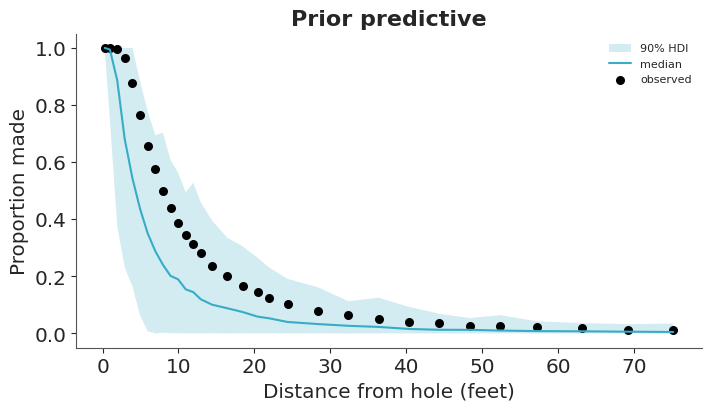

In [6]:
plot_rate(
    prior["prior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Prior predictive",
);

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.97,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_logit'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

local_rhat = idata["posterior"]["eta"].azstats.rhat()
local_ess = idata["posterior"]["eta"].azstats.ess(method="bulk")
print(f"Worst eta R-hat: {float(local_rhat.max()):.3f}")
print(f"Smallest eta bulk ESS: {float(local_ess.min()):.0f}")

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Divergences: 0
Worst eta R-hat: 1.022
Smallest eta bulk ESS: 298


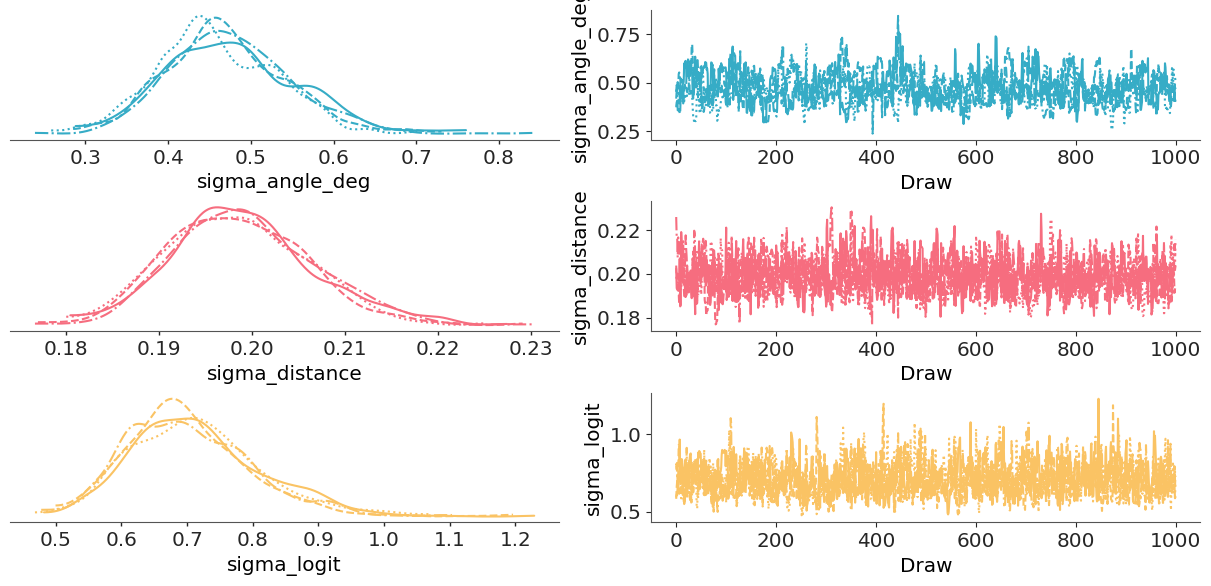

In [8]:
azp.plot_trace_dist(idata, var_names=['sigma_angle_deg', 'sigma_distance', 'sigma_logit']);

## Posterior fit

This plot shows posterior uncertainty in the continuous underlying mechanism $p_{base}(x)$ **before** the local discrepancy terms are applied. That distinction matters: the full model can fit the data by using local corrections even when the shared mechanism still has systematic structure.

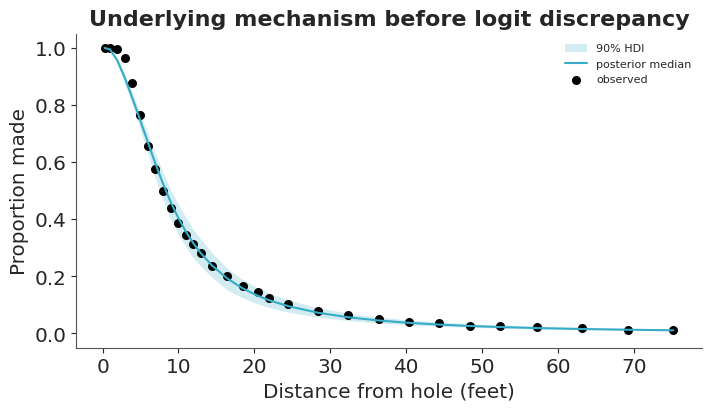

In [9]:
plot_rate(
    idata["posterior"]["p_base"],
    golf,
    "Underlying mechanism before logit discrepancy",
    median_label="posterior median",
);

## Posterior predictive check

Now generate new outcomes at the same putting distances from the **full fitted model**, including its local discrepancy terms. This uses the same graphical grammar as the prior predictive check; the difference is conditioning on the observed data.

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["made"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Output()

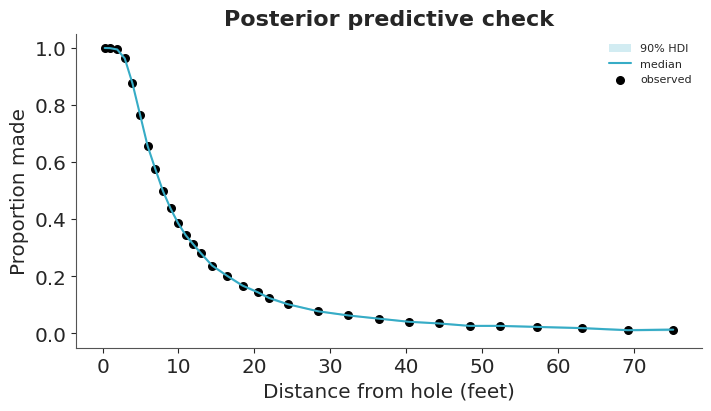

In [11]:
plot_rate(
    idata["posterior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Posterior predictive check",
);

## Model criticism

These residuals deliberately compare the observations with $p_{base}(x)$, before the bin-specific discrepancy terms. They ask whether the shared mechanism still misses a systematic feature that the local corrections are masking.

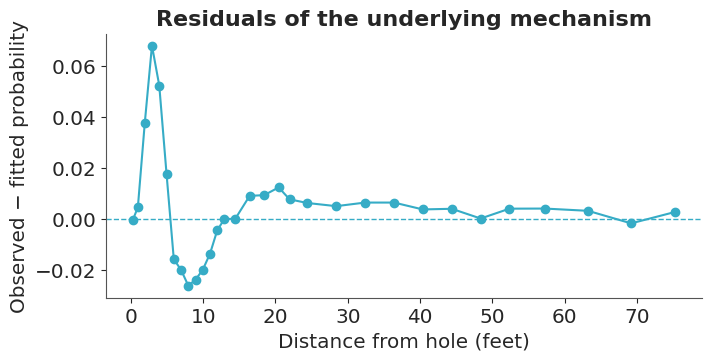

In [12]:
plot_residuals(idata, golf, var_name="p_base", title="Residuals of the underlying mechanism");

## Decision: reject this discrepancy structure

The local logit errors can absorb a great deal, but the underlying mechanistic relationship is distorted especially at the shortest distances, and this formulation can also be computationally awkward. The discrepancy is symmetric on the logit scale even though the physical simplification is more naturally thought of as **additional ways to miss**, which can only reduce the idealized success probability. **Next notebook:** use proportional downward errors.